In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
import matplotlib.pylab as pylab
import matplotlib.axes as axes
from scipy.optimize import curve_fit
import ROOT

params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'xtick.direction':'in',
         'ytick.direction':'in',
         'xtick.bottom':'True',
         'xtick.top':'True',
         'ytick.right':'True',
         'xtick.major.width':1.5,
         'ytick.major.width':1.5,
         'xtick.major.size':6,
         'ytick.major.size':6}
pylab.rcParams.update(params)

Linestyle = 'solid'
Linestyle2 = 'dashed'
Linestyle3 = 'dotted'
Linestyle4 = (0,(5,10))
Linestyle5 = "None"

Welcome to JupyROOT 6.30/04


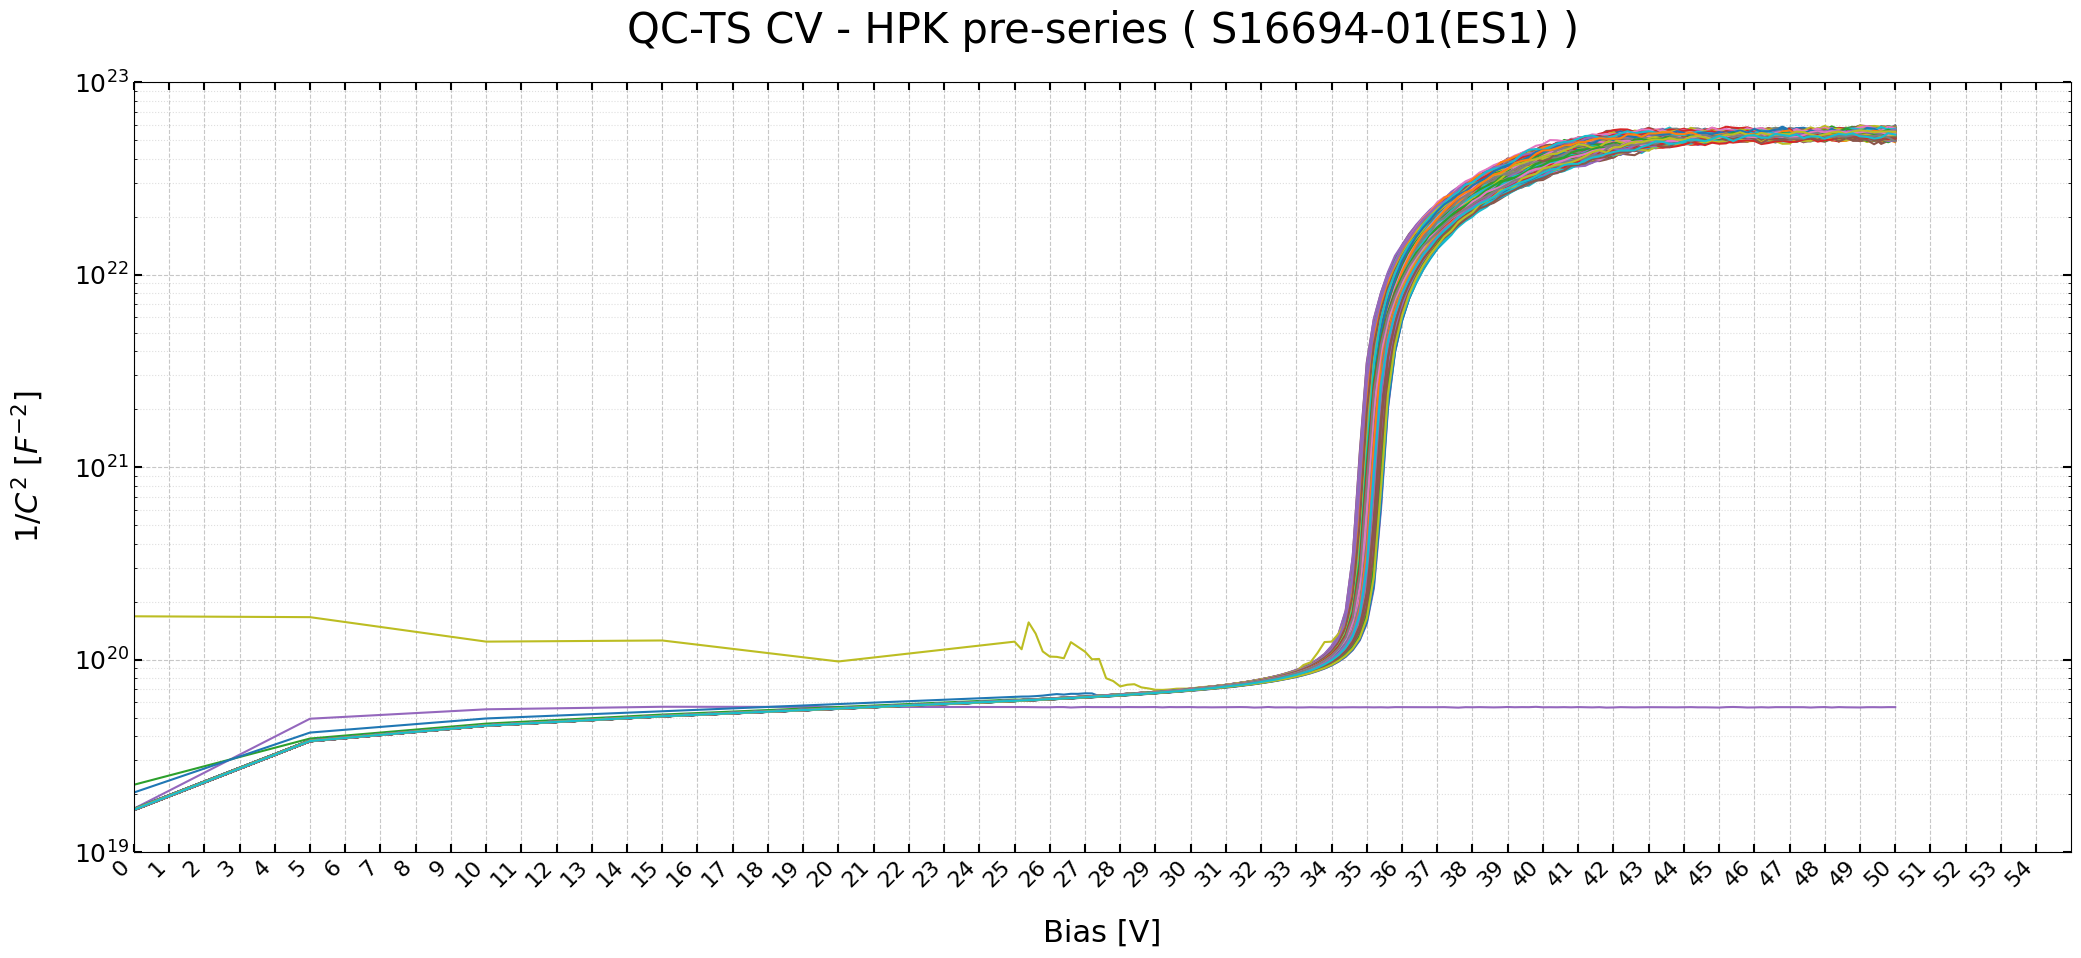

In [2]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker # <--- Importante per i locators

def plot_cv_curves_on_same_plot(root_file, tree_name="Tree"):
    """
    Plots all IV curves from a ROOT tree on the same plot.

    Args:
        root_file: Path to the ROOT file.
        tree_name: Name of the tree in the ROOT file.

    Returns:
        None (displays the plot).
    """

    file_qa = ROOT.TFile.Open(root_file)
    tree_qa = file_qa.Get(tree_name)

    plt.figure(figsize=(25, 10))  # Adjust figure size as needed

    for i, event in enumerate(tree_qa):
        #if event.wafer==49 and event.sensor==3:
        #if event.wafer==1 and (event.sensor==3 or event.sensor==15):
            cpad_values = np.array(event.CPAD, dtype=float)
            cpad_inv = 1./(cpad_values**2)
            v_values = np.array(event.V, dtype=float)
            #v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, cpad_inv, label=f"Wafer: {event.wafer} - Sensor: {event.sensor}") 
    
    
            
    plt.xlabel("Bias [V]", fontsize=22, labelpad=20)
    plt.ylabel("1/$C^{2}$ [$F^{-2}$]", fontsize=22, labelpad=20)
    plt.yscale('log')
    
    #y_ticks_major = np.arange(0, 76, 5)
    x_ticks_major = np.arange(0, 55, 1)
    
    #plt.yticks(y_ticks_major)
    plt.xticks(x_ticks_major)
    plt.xticks(fontsize=16, rotation=45, ha='right')
    plt.yticks(fontsize=18)
    
    plt.xlim(0, 55) 
    plt.ylim(1e19, 1e23) 
    
    # --- CONFIGURAZIONE MINOR TICKS LOG ---
    # Usiamo plt.gca() per accedere alle proprietà dell'asse corrente
    ax = plt.gca()
    # Forza la comparsa di un tick per ogni decade (base 10)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
    # Imposta i minor ticks per la scala logaritmica (i multipli da 2 a 9)
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(.2, .3, .4, .5, .6, .7, .8, .9), numticks=12))
    # Rende i minor ticks invisibili come testo (solo segni grafici)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
    # Griglie: differenziamo major e minor per leggibilità
    plt.grid(True, which="major", axis='both', linestyle='--', alpha=0.7)
    plt.grid(True, which="minor", axis='y', linestyle=':', alpha=0.4)
    
    #plt.grid(axis='x', linestyle='--', alpha=0.7)
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title("QC-TS CV - HPK pre-series ( S16694-01(ES1) )", fontsize=30, y=1.04)
    #plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()

    file_qa.Close()

# Example usage:
root_file = "/Users/icosivi/Desktop/PRE-SERIE/HPK/PRE-SERIE_HPK_Vendor_QC-TS_CV.root" 
plot_cv_curves_on_same_plot(root_file)

In [ ]:
import ROOT
import os
from IPython.display import display, Image

def plot_multigraph_notebook(wafer, sensor, base_path="/Users/icosivi/Desktop/PRE-SERIE/HPK/CV_plots/"):
    """
    Versione ottimizzata per Notebook: apre il file .root, disegna il TMultiGraph
    e visualizza l'immagine direttamente nella cella.
    """
    # Costruzione nomi
    filename = f"W{wafer}_S{sensor}.root"
    filepath = os.path.join(base_path, filename)
    object_name = f"W{wafer}_S{sensor}"
    
    # 1. Verifica file
    if not os.path.exists(filepath):
        print(f"Errore: File {filepath} non trovato.")
        return

    # 2. Apertura file
    file_root = ROOT.TFile.Open(filepath, "READ")
    if not file_root or file_root.IsZombie():
        print(f"Errore: Apertura fallita per {filename}")
        return

    # 3. Recupero oggetto
    mg = file_root.Get(object_name)
    if not mg:
        print(f"Errore: Oggetto '{object_name}' non trovato.")
        file_root.Close()
        return

    # 4. Configurazione Canvas "Batch Mode"
    # Il flag kTRUE su SetBatch evita il tentativo di aprire finestre esterne
    ROOT.gROOT.SetBatch(ROOT.kTRUE)
    
    canvas_name = f"c_nb_{wafer}_{sensor}"
    c1 = ROOT.TCanvas(canvas_name, "Plot", 800, 600)
    c1.SetGrid()
    
    # Disegno del MultiGraph
    mg.Draw("APL")
    
    # Se vuoi migliorare la leggibilità nel notebook
    mg.GetXaxis().SetTitle("Tensione [V]")
    mg.GetYaxis().SetTitle("Capacità [F]") # o il tuo parametro
    
    c1.Update()
    c1.Modified()

    # 5. Rendering per il Notebook
    # Salviamo in un file temporaneo per mostrarlo nella cella
    temp_img = "temp_plot.png"
    c1.SaveAs(temp_img)
    
    # Chiudiamo le risorse ROOT
    file_root.Close()
    
    # Visualizziamo l'immagine nel notebook
    display(Image(filename=temp_img))
    
    # Pulizia file temporaneo (opzionale)
    # os.remove(temp_img)

# --- Esecuzione nella cella ---
# Inserisci i valori desiderati qui sotto
plot_multigraph_notebook(wafer=83, sensor=3)